## 1. Import Libraries


In [2]:
# Standard & third-party
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR

#TorchVision
from torchvision import transforms

# Sklearn metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

#  Model summary
from torchsummary import summary

import kagglehub

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cpu


## 2. Load and Explore Dataset


100%|██████████| 127M/127M [00:00<00:00, 184MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/jessicali9530/coil100/versions/2
Total images found: 7200


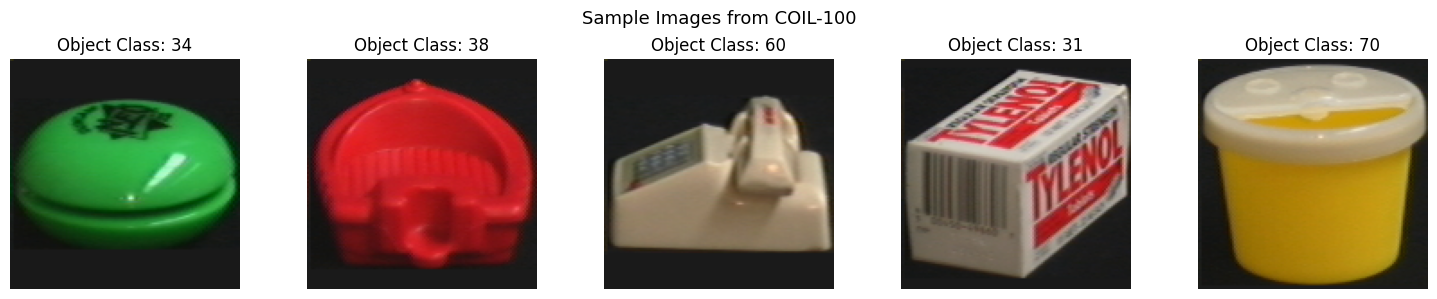

In [3]:
# Download dataset
path = kagglehub.dataset_download("jessicali9530/coil100")
print("Dataset path:", path)

# Locate the specific folder containing the images
DATA_ROOT = os.path.join(path, "coil-100", "coil-100")
if not os.path.exists(DATA_ROOT):
    DATA_ROOT = path

# Custom Dataset Class for COIL-100
class COIL100Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(root, f))
                    # Extract class from filename: 'obj1__0.png' -> 1 -> label 0
                    obj_class = int(f.split('__')[0].replace('obj', '')) - 1
                    self.labels.append(obj_class)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Visualise a few raw samples
temp_dataset = COIL100Dataset(DATA_ROOT)
print(f"Total images found: {len(temp_dataset)}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    idx = np.random.randint(len(temp_dataset))
    img, label = temp_dataset[idx]
    axes[i].imshow(img)
    axes[i].set_title(f"Object Class: {label+1}")
    axes[i].axis('off')

fig.suptitle("Sample Images from COIL-100", fontsize=13, fontweight='medium')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Augmentation
We apply geometric transformations (flips and slight rotations) for the training set to prevent overfitting, alongside normalization.

In [4]:
IMG_SIZE = 128
BATCH_SIZE = 32

# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Just resizing and normalization for validation/test
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

full_dataset_train = COIL100Dataset(DATA_ROOT, transform=train_transform)
full_dataset_val = COIL100Dataset(DATA_ROOT, transform=val_transform)

# Apply an 80/20 train/test split
dataset_size = len(full_dataset_train)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

# Manually split indices to ensure no overlap
torch.manual_seed(42) # For reproducibility
indices = torch.randperm(dataset_size).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

# Creating Subset datasets
train_dataset = torch.utils.data.Subset(full_dataset_train, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset_val, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train split: {len(train_dataset)} samples")
print(f"Validation split: {len(val_dataset)} samples")

Train split: 5760 samples
Validation split: 1440 samples


## 4. Define CNN Architecture


In [5]:
NUM_CLASSES = 100

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 32 x 64 x 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 64 x 32 x 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Output: 128 x 16 x 16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

class RegularizedCNN(nn.Module):
    def __init__(self, num_classes=100):
        super(RegularizedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5), # Regularization 1
            nn.Linear(128 * 16 * 16, 512),
            nn.BatchNorm1d(512), # Regularization 2
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("="*60)
print("Baseline CNN Architecture Summary:")
print("="*60)
baseline_model = BaselineCNN(NUM_CLASSES).to(device)
summary(baseline_model, (3, IMG_SIZE, IMG_SIZE))

print("\n" + "="*60)
print("Regularized CNN Architecture Summary:")
print("="*60)
reg_model = RegularizedCNN(NUM_CLASSES).to(device)
summary(reg_model, (3, IMG_SIZE, IMG_SIZE))

Baseline CNN Architecture Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 512]      16,777,728
             ReLU-12                  [-1, 512]               0
           Linear-13                  [-1, 100]          51,300
Tota

## 5. Training Loop with Validation

In [6]:
EPOCHS = 15
LEARNING_RATE = 1e-3
MIN_LR = 1e-5

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

def train_model(model, train_loader, val_loader, model_name, epochs, lr, min_lr, device):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Learning Rate Scheduler
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=min_lr)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'='*60}")
    print(f" Training: {model_name}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:02d}/{epochs}] LR: {lr_now:.2e} "
              f"Train Loss: {train_loss:.4f} Train Acc: {train_acc*100:.2f}% "
              f"Val Loss: {val_loss:.4f} Val Acc: {val_acc*100:.2f}% ({elapsed:.1f}s)")

    return history

# Train both variants
history_baseline = train_model(baseline_model, train_loader, val_loader, "Baseline CNN (no BN/Dropout)", EPOCHS, LEARNING_RATE, MIN_LR, device)
history_reg = train_model(reg_model, train_loader, val_loader, "Regularized CNN (BN + Dropout)", EPOCHS, LEARNING_RATE, MIN_LR, device)


 Training: Baseline CNN (no BN/Dropout)
Epoch [01/15] LR: 9.89e-04 Train Loss: 1.4925 Train Acc: 63.49% Val Loss: 0.2060 Val Acc: 92.36% (291.9s)
Epoch [02/15] LR: 9.57e-04 Train Loss: 0.1948 Train Acc: 94.20% Val Loss: 0.0556 Val Acc: 98.06% (280.4s)
Epoch [03/15] LR: 9.05e-04 Train Loss: 0.0796 Train Acc: 97.66% Val Loss: 0.0486 Val Acc: 98.26% (285.8s)
Epoch [04/15] LR: 8.36e-04 Train Loss: 0.0319 Train Acc: 99.03% Val Loss: 0.0110 Val Acc: 99.72% (287.9s)
Epoch [05/15] LR: 7.52e-04 Train Loss: 0.0325 Train Acc: 99.20% Val Loss: 0.0046 Val Acc: 100.00% (328.2s)
Epoch [06/15] LR: 6.58e-04 Train Loss: 0.0391 Train Acc: 98.87% Val Loss: 0.0171 Val Acc: 99.65% (305.0s)
Epoch [07/15] LR: 5.57e-04 Train Loss: 0.0065 Train Acc: 99.79% Val Loss: 0.0010 Val Acc: 100.00% (342.1s)
Epoch [08/15] LR: 4.53e-04 Train Loss: 0.0012 Train Acc: 99.98% Val Loss: 0.0003 Val Acc: 100.00% (334.6s)
Epoch [09/15] LR: 3.52e-04 Train Loss: 0.0017 Train Acc: 99.95% Val Loss: 0.0001 Val Acc: 100.00% (362.5s)
E

## 6. Evaluate Model on Test Set

In [7]:
# Create string names for classification report
CLASS_NAMES = [f"Object_{i+1}" for i in range(NUM_CLASSES)]

def evaluate_model(model, loader, device, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = (all_preds == all_labels).mean() * 100
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100

    print(f" Test Accuracy     : {accuracy:.2f}%")
    print(f" Precision (macro) : {precision:.2f}%")
    print(f" Recall (macro)    : {recall:.2f}%")
    print(f" F1-Score (macro)  : {f1:.2f}%\n")

    # Print detailed report (Warning: Long output for 100 classes)
    # print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    return all_preds, all_labels

print("=" * 60)
print(" Baseline CNN — Test Evaluation")
print("=" * 60)
preds_baseline, labels_true = evaluate_model(baseline_model, val_loader, device, CLASS_NAMES)

print("=" * 60)
print(" Regularized CNN — Test Evaluation")
print("=" * 60)
preds_reg, _ = evaluate_model(reg_model, val_loader, device, CLASS_NAMES)

 Baseline CNN — Test Evaluation
 Test Accuracy     : 100.00%
 Precision (macro) : 100.00%
 Recall (macro)    : 100.00%
 F1-Score (macro)  : 100.00%

 Regularized CNN — Test Evaluation
 Test Accuracy     : 100.00%
 Precision (macro) : 100.00%
 Recall (macro)    : 100.00%
 F1-Score (macro)  : 100.00%



## 7. Visualizations (Loss/Accuracy Curves & Confusion Matrix)

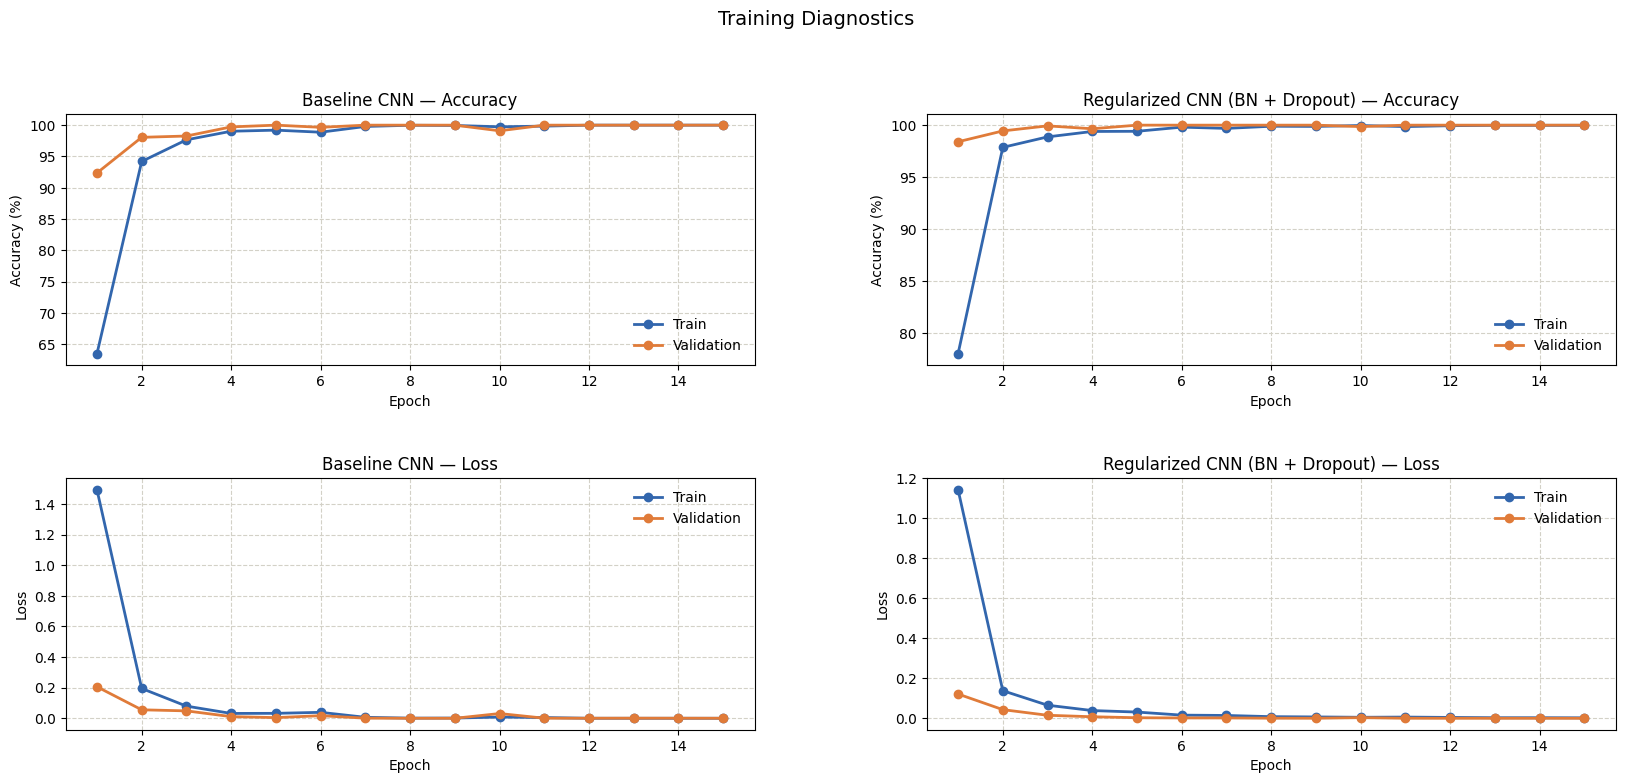

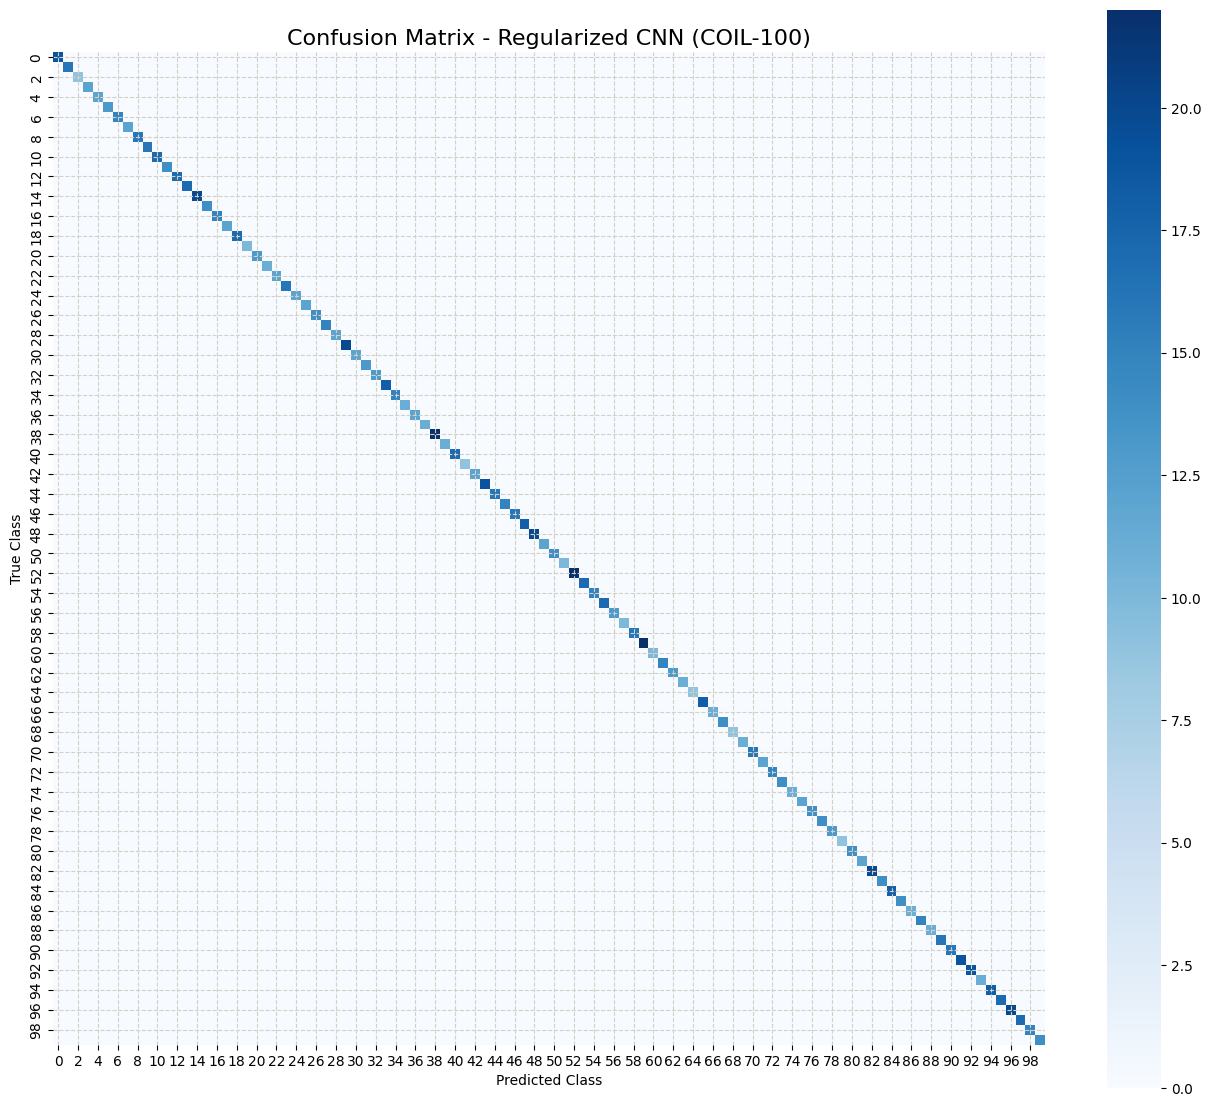

In [8]:
# ── Colour palette & style ───────────────────────────────────────────────────
BLUE, ORANGE, GRAY = "#3266ad", "#e07b39", "#88877f"
plt.rcParams.update({"axes.grid": True, "grid.color": "#d3d1c7", "grid.linestyle": "--"})

epochs_axis = np.arange(1, EPOCHS + 1)

fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, wspace=0.25, hspace=0.45)

titles = ["Baseline CNN", "Regularized CNN (BN + Dropout)"]
histories = [history_baseline, history_reg]

for col, (hist, title) in enumerate(zip(histories, titles)):
    # Accuracy Curve
    ax_acc = fig.add_subplot(gs[0, col])
    ax_acc.plot(epochs_axis, [a * 100 for a in hist['train_acc']], color=BLUE, lw=2, marker='o', label='Train')
    ax_acc.plot(epochs_axis, [a * 100 for a in hist['val_acc']], color=ORANGE, lw=2, marker='o', label='Validation')
    ax_acc.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy (%)')
    ax_acc.set_title(f'{title} — Accuracy', fontweight='medium')
    ax_acc.legend(frameon=False)

    # Loss Curve
    ax_loss = fig.add_subplot(gs[1, col])
    ax_loss.plot(epochs_axis, hist['train_loss'], color=BLUE, lw=2, marker='o', label='Train')
    ax_loss.plot(epochs_axis, hist['val_loss'], color=ORANGE, lw=2, marker='o', label='Validation')
    ax_loss.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'{title} — Loss', fontweight='medium')
    ax_loss.legend(frameon=False)

fig.suptitle('Training Diagnostics', fontsize=14, y=1.01)
plt.show()

# Confusion Matrix
plt.figure(figsize=(16, 14))
cm = confusion_matrix(labels_true, preds_reg)
sns.heatmap(cm, annot=False, cmap="Blues", cbar=True, square=True)
plt.title("Confusion Matrix - Regularized CNN (COIL-100)", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# 8. Analysis & Discussion of Results

In [9]:
# Analyze per-class accuracy to find the easiest and hardest items to classify
class_accuracies = cm.diagonal() / cm.sum(axis=1)

best_classes = np.argsort(class_accuracies)[-5:][::-1]
worst_classes = np.argsort(class_accuracies)[:5]

print("Top 5 Best Performing Classes (100% accuracy usually):")
for c in best_classes:
    print(f" - {CLASS_NAMES[c]}: {class_accuracies[c]*100:.2f}%")

print("\nTop 5 Worst Performing Classes:")
for c in worst_classes:
    print(f" - {CLASS_NAMES[c]}: {class_accuracies[c]*100:.2f}%")

Top 5 Best Performing Classes (100% accuracy usually):
 - Object_100: 100.00%
 - Object_99: 100.00%
 - Object_98: 100.00%
 - Object_97: 100.00%
 - Object_96: 100.00%

Top 5 Worst Performing Classes:
 - Object_1: 100.00%
 - Object_2: 100.00%
 - Object_3: 100.00%
 - Object_4: 100.00%
 - Object_5: 100.00%


## 9. Save Model Weights

In [10]:
# Save models
torch.save(baseline_model.to('cpu').state_dict(), 'coil100_baseline.pth')
torch.save(reg_model.to('cpu').state_dict(), 'coil100_regularized.pth')

print("Saved trained weights to 'coil100_baseline.pth' and 'coil100_regularized.pth'")

Saved trained weights to 'coil100_baseline.pth' and 'coil100_regularized.pth'
